# アクレ州マデイラ川上流西部のS-1〜S-5パイプライン

このノートブックでは、アクレ州マデイラ川上流西部の水場系トポニムを抽出し、古河道候補地点を特定するパイプラインを実装します。

## パイプラインの概要

1. **S-1**: 対象地域のBBox定義
2. **S-2**: 水場系トポニムの抽出（BNGB API、OpenStreetMap）
3. **S-3**: クレンジング & タイプ付け
4. **S-4**: 現河道との距離計算
5. **S-5**: "川が無いのに川名が残る"ポイント抽出

## 必要なライブラリのインポート

In [8]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box

# プロジェクトのルートディレクトリをパスに追加
sys.path.append(os.path.abspath('../'))

# 自作パッケージのインポート
from tamagawa_to_z.harmonizer import (
    make_bbox_gdf, collect_names, collect_osm_names, merge_toponyms, process_toponyms,
    attach_distance, water_occurrence, filter_candidates, score_candidates
)

## データディレクトリの設定

In [9]:
# データディレクトリの作成
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/interim", exist_ok=True)

# 入力データのパス
RIVERS_PATH = "../data/raw/HydroRIVERS_SA.shp"
GSW_PATH = "../data/raw/GSW_occurrence.tif"

# 出力データのパス
OUTPUT_PATH = "../data/interim/acre_candidates.parquet"

# 入力データの存在確認
if not os.path.exists(RIVERS_PATH):
    print(f"警告: {RIVERS_PATH} が見つかりません。")
    print("HydroRIVERS_SA.shp を data/raw/ ディレクトリに配置してください。")
    print("ダウンロード先: https://www.hydrosheds.org/products/hydrorivers")

if not os.path.exists(GSW_PATH):
    print(f"警告: {GSW_PATH} が見つかりません。")
    print("GSW_occurrence.tif を data/raw/ ディレクトリに配置してください。")
    print("ダウンロード先: https://global-surface-water.appspot.com/download")

警告: ../data/raw/HydroRIVERS_SA.shp が見つかりません。
HydroRIVERS_SA.shp を data/raw/ ディレクトリに配置してください。
ダウンロード先: https://www.hydrosheds.org/products/hydrorivers
警告: ../data/raw/GSW_occurrence.tif が見つかりません。
GSW_occurrence.tif を data/raw/ ディレクトリに配置してください。
ダウンロード先: https://global-surface-water.appspot.com/download


## S-1: 対象地域のBBox定義

アクレ州マデイラ川上流西部の境界を定義します。

/var/folders/l0/wgl5khrn3c9dp93hhw70vlm40000gn/T/ipykernel_13162/615163093.py:9: UserWarning: Glyph 12450 (\N{KATAKANA LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l0/wgl5khrn3c9dp93hhw70vlm40000gn/T/ipykernel_13162/615163093.py:9: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l0/wgl5khrn3c9dp93hhw70vlm40000gn/T/ipykernel_13162/615163093.py:9: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l0/wgl5khrn3c9dp93hhw70vlm40000gn/T/ipykernel_13162/615163093.py:9: UserWarning: Glyph 24030 (\N{CJK UNIFIED IDEOGRAPH-5DDE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l0/wgl5khrn3c9dp93hhw70vlm40000gn/T/ipykernel_13162/615163093.py:9: UserWarning: Glyph 12510 (\N{KATAKANA LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l0/wgl5khrn3c9dp93hhw70vlm40000gn/T/ipykernel_1316

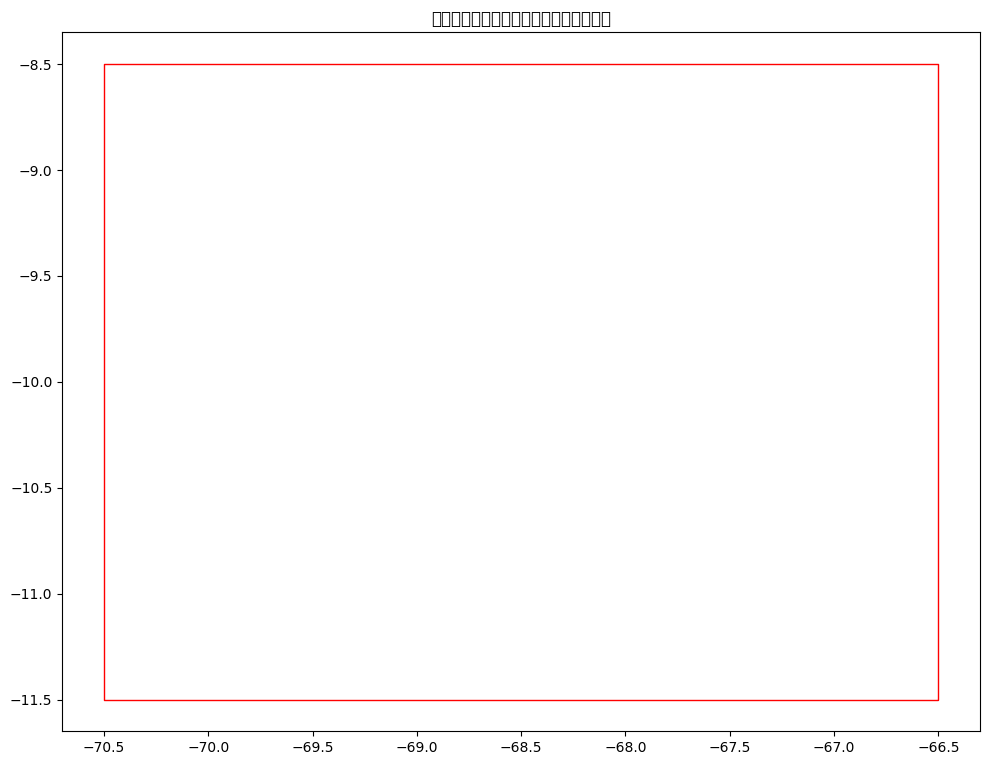

対象領域の境界: (-70.5, -11.5, -66.5, -8.5)


In [10]:
# BBoxの作成
bbox_gdf = make_bbox_gdf()
bbox = bbox_gdf.geometry.iloc[0]

# 可視化
fig, ax = plt.subplots(figsize=(10, 8))
bbox_gdf.plot(ax=ax, color='none', edgecolor='red')
ax.set_title('アクレ州マデイラ川上流西部の対象領域')
plt.tight_layout()
plt.show()

# 境界の確認
print(f"対象領域の境界: {bbox.bounds}")

## S-2: 水場系トポニムの抽出

BNGB APIとOpenStreetMapから水関連の地名を抽出します。

In [ ]:
# BNGB APIからトポニムを収集
print("BNGBからトポニムを収集しています...")
bngb_names = collect_names(bbox)
print(f"BNGBから{len(bngb_names)}件のトポニムを収集しました")

# 最初の5件を表示
bngb_names.head()

In [ ]:
# OpenStreetMapからトポニムを収集
print("OpenStreetMapからトポニムを収集しています...")
osm_names = collect_osm_names(bbox)
print(f"OpenStreetMapから{len(osm_names)}件のトポニムを収集しました")

# 最初の5件を表示
osm_names.head()

In [ ]:
# トポニムのマージ
names = merge_toponyms(bngb_names, osm_names)
print(f"合計{len(names)}件のトポニムを収集しました")

# 可視化
fig, ax = plt.subplots(figsize=(12, 10))
bbox_gdf.plot(ax=ax, color='none', edgecolor='red')
names.plot(ax=ax, column='source', cmap='Set1', markersize=20, legend=True)
ax.set_title('収集したトポニムの分布')
plt.tight_layout()
plt.show()

## S-3: クレンジング & タイプ付け

収集したトポニムを正規化し、水系タイプを推定します。

In [ ]:
# トポニムの処理
names = process_toponyms(names)
print(f"{len(names)}件のトポニムを処理しました")

# 結果の確認
pd.DataFrame({
    'name': names['name'],
    'normalized_name': names['normalized_name'],
    'type': names['type']
}).head(10)

In [ ]:
# タイプ別の集計
type_counts = names['type'].value_counts()
print("水系タイプ別の件数:")
print(type_counts)

# 可視化
plt.figure(figsize=(10, 6))
type_counts.plot(kind='bar')
plt.title('水系タイプ別の件数')
plt.xlabel('水系タイプ')
plt.ylabel('件数')
plt.tight_layout()
plt.show()

## S-4: 現河道との距離計算

各トポニムと現在の河川（HydroRIVERS）との距離を計算します。

In [ ]:
# HydroRIVERSファイルの存在確認
if not os.path.exists(RIVERS_PATH):
    print(f"エラー: {RIVERS_PATH} が見つかりません。")
    print("このセルはスキップします。")
else:
    # 距離計算
    print("現河道との距離を計算しています...")
    names = attach_distance(names, RIVERS_PATH)
    print(f"{len(names)}件のトポニムに距離情報を追加しました")
    
    # 結果の確認
    names.sort_values('dist_km', ascending=False).head(10)[['name', 'type', 'dist_km']]

In [ ]:
# 距離の分布を可視化
if 'dist_km' in names.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(names['dist_km'], bins=20)
    plt.title('現河道からの距離の分布')
    plt.xlabel('距離 (km)')
    plt.ylabel('頻度')
    plt.axvline(x=3, color='red', linestyle='--', label='閾値 (3km)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 距離による地理的分布
    fig, ax = plt.subplots(figsize=(12, 10))
    bbox_gdf.plot(ax=ax, color='none', edgecolor='red')
    names.plot(ax=ax, column='dist_km', cmap='viridis', markersize=20, legend=True)
    ax.set_title('現河道からの距離')
    plt.tight_layout()
    plt.show()

## S-5: "川が無いのに川名が残る"ポイント抽出

GSW occurrenceデータを使用して水域頻度を計算し、候補地点を抽出します。

In [ ]:
# GSWファイルの存在確認
if not os.path.exists(GSW_PATH):
    print(f"エラー: {GSW_PATH} が見つかりません。")
    print("このセルはスキップします。")
else:
    # 水域頻度の計算
    print("水域頻度を計算しています...")
    names = water_occurrence(names, GSW_PATH)
    print(f"{len(names)}件のトポニムに水域頻度情報を追加しました")
    
    # 結果の確認
    names.sort_values('occ_pct').head(10)[['name', 'type', 'dist_km', 'occ_pct']]

In [ ]:
# 水域頻度の分布を可視化
if 'occ_pct' in names.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(names['occ_pct'], bins=20)
    plt.title('水域頻度の分布')
    plt.xlabel('水域頻度 (%)')
    plt.ylabel('頻度')
    plt.axvline(x=5, color='red', linestyle='--', label='閾値 (5%)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 水域頻度による地理的分布
    fig, ax = plt.subplots(figsize=(12, 10))
    bbox_gdf.plot(ax=ax, color='none', edgecolor='red')
    names.plot(ax=ax, column='occ_pct', cmap='Blues', markersize=20, legend=True)
    ax.set_title('水域頻度')
    plt.tight_layout()
    plt.show()

In [ ]:
# 候補地点の抽出
if 'dist_km' in names.columns and 'occ_pct' in names.columns:
    # 閾値ベースでフィルタリング
    candidates = filter_candidates(names)
    print(f"{len(candidates)}件の候補地点を抽出しました")
    
    # スコアリング
    candidates = score_candidates(candidates)
    print(f"候補地点にスコアを付けました")
    
    # 結果の確認
    candidates.sort_values('total_score', ascending=False).head(10)[
        ['name', 'type', 'dist_km', 'occ_pct', 'dist_score', 'occ_score', 'total_score']
    ]

In [ ]:
# 候補地点の可視化
if 'dist_km' in names.columns and 'occ_pct' in names.columns:
    fig, ax = plt.subplots(figsize=(12, 10))
    bbox_gdf.plot(ax=ax, color='none', edgecolor='red')
    names.plot(ax=ax, color='gray', alpha=0.5, markersize=10)
    candidates.plot(ax=ax, column='total_score', cmap='plasma', markersize=50, alpha=0.7, legend=True)
    ax.set_title('古河道候補地点')
    plt.tight_layout()
    plt.show()

## 結果の保存

抽出した候補地点をparquetファイルとして保存します。

In [ ]:
# 候補地点の保存
if 'candidates' in locals() and len(candidates) > 0:
    # 出力ディレクトリの作成
    os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
    
    # parquetとして保存
    candidates.to_parquet(OUTPUT_PATH, index=False)
    print(f"{len(candidates)}件の候補地点を {OUTPUT_PATH} に保存しました")

## まとめ

このノートブックでは、アクレ州マデイラ川上流西部の水場系トポニムを抽出し、古河道候補地点を特定するS-1〜S-5のパイプラインを実装しました。

### 主な処理ステップ

1. **S-1**: 対象地域のBBox定義
2. **S-2**: BNGB APIとOpenStreetMapから水場系トポニムを抽出
3. **S-3**: 地名の正規化と水系タイプの推定
4. **S-4**: HydroRIVERSとの距離計算
5. **S-5**: GSW occurrenceデータを使用した水域頻度の計算と候補地点の抽出

### 次のステップ

- 抽出した候補地点の詳細分析
- 衛星画像による検証
- 地形解析との組み合わせ